# Stock Market Project — Exploratory Data Analysis

This notebook performs exploratory data analysis for a multi-stock daily price dataset.

## Goals
- inspect data quality issues such as missing values and duplicates
- study price and return distributions
- check volatility clustering and extreme market moves
- compare stock-by-stock behavior
- explore relationships between engineered features and the prediction target
- compare important market regimes such as the 2020 crash and the 2022 drawdown

This EDA will help motivate later modeling choices for forecasting, survival analysis, and ranking.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy.stats import zscore

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 1. Load data

This notebook assumes you already downloaded the stock data into your project folder.  
Adjust the candidate paths below if your CSV has a different name.

In [6]:
data_path = Path("../01_data/raw/stock_prices.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (19836, 8)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL


## 2. Basic cleaning and setup

We first standardize column types and sort the data by ticker and date.

In [7]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

required_cols = ["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]
missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

price_col = "Adj Close" if "Adj Close" in df.columns else "Close"

print("Using price column for return calculations:", price_col)
df.head()

Using price column for return calculations: Adj Close


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL


## 3. Feature engineering for EDA

These features will also be useful later for modeling:
- daily return
- lagged returns
- rolling volatility
- daily volume change
- next-day return target

In [8]:
df_eda = df.copy()

if "Return_1d" not in df_eda.columns:
    df_eda["Return_1d"] = df_eda.groupby("Ticker")[price_col].pct_change(1)

if "Return_3d" not in df_eda.columns:
    df_eda["Return_3d"] = df_eda.groupby("Ticker")[price_col].pct_change(3)

if "Return_5d" not in df_eda.columns:
    df_eda["Return_5d"] = df_eda.groupby("Ticker")[price_col].pct_change(5)

if "Volatility_5d" not in df_eda.columns:
    df_eda["Volatility_5d"] = (
        df_eda.groupby("Ticker")["Return_1d"]
        .rolling(5)
        .std()
        .reset_index(level=0, drop=True)
    )

if "Volatility_20d" not in df_eda.columns:
    df_eda["Volatility_20d"] = (
        df_eda.groupby("Ticker")["Return_1d"]
        .rolling(20)
        .std()
        .reset_index(level=0, drop=True)
    )

if "Volume_Change_1d" not in df_eda.columns:
    df_eda["Volume_Change_1d"] = df_eda.groupby("Ticker")["Volume"].pct_change(1)

if "Target_Return_1d" not in df_eda.columns:
    df_eda["Target_Return_1d"] = (
        df_eda.groupby("Ticker")[price_col]
        .pct_change(1)
        .shift(-1)
    )

df_eda["Weekday"] = df_eda["Date"].dt.day_name()
df_eda["Month"] = df_eda["Date"].dt.month_name()

df_eda.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Return_1d,Weekday,Month
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,0.001729,Monday,January
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL,0.001729,NaN,NaN,NaN,NaN,0.219098,-0.015906,Tuesday,January
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL,-0.015906,NaN,NaN,NaN,NaN,-0.082646,-0.001849,Wednesday,January
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016028,NaN,NaN,NaN,-0.135882,0.006648,Thursday,January
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL,0.006648,-0.011195,NaN,NaN,NaN,-0.061871,-0.008821,Friday,January


## 4. Data overview

In [9]:
print("Rows, columns:", df_eda.shape)
print("\nTickers:", sorted(df_eda["Ticker"].unique()))
print("\nDate range:", df_eda["Date"].min().date(), "to", df_eda["Date"].max().date())

display(df_eda.info())
display(df_eda.describe(include="all").T.head(20))

Rows, columns: (19836, 17)

Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']

Date range: 2010-01-04 to 2026-04-02
<class 'pandas.DataFrame'>
RangeIndex: 19836 entries, 0 to 19835
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              19836 non-null  datetime64[us]
 1   Open              19836 non-null  float64       
 2   High              19836 non-null  float64       
 3   Low               19836 non-null  float64       
 4   Close             19836 non-null  float64       
 5   Adj Close         19836 non-null  float64       
 6   Volume            19836 non-null  int64         
 7   Ticker            19836 non-null  str           
 8   Return_1d         19831 non-null  float64       
 9   Return_3d         19821 non-null  float64       
 10  Return_5d         19811 non-null  float64       
 11  Volatility_5d     19811 non-null  float64       
 12  Volatility_20d    19736 

None

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,19836,NaN,NaN,NaN,2018-05-01 18:55:14.700544,2010-01-04 00:00:00,2014-06-04 00:00:00,2018-05-11 00:00:00,2022-04-20 00:00:00,2026-04-02 00:00:00,NaN
Open,"19,836.000000",NaN,NaN,NaN,122.546094,5.296500,28.239375,75.959999,171.865002,791.150024,130.775787
High,"19,836.000000",NaN,NaN,NaN,123.900128,5.564500,28.500000,76.879997,173.696621,796.250000,132.200589
Low,"19,836.000000",NaN,NaN,NaN,121.156790,5.290000,27.950001,75.169250,170.000000,780.820007,129.225537
Close,"19,836.000000",NaN,NaN,NaN,122.565474,5.430500,28.219999,75.943249,171.972500,790.000000,130.731203
Adj Close,"19,836.000000",NaN,NaN,NaN,120.352642,5.430500,25.904945,75.074097,170.332066,788.148987,130.322256
Volume,"19,836.000000",NaN,NaN,NaN,"84,603,550.423271","4,726,100.000000","26,583,700.000000","46,335,250.000000","86,855,795.000000","1,880,998,000.000000","124,536,466.775286"
Ticker,19836,5,AAPL,4087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Return_1d,"19,831.000000",NaN,NaN,NaN,0.000975,-0.263901,-0.008165,0.000866,0.010561,0.296115,0.019469
Return_3d,"19,821.000000",NaN,NaN,NaN,0.002920,-0.303684,-0.014328,0.003287,0.020366,0.336477,0.032918


## 5. Missing values

Missing values are common in time-series feature engineering because rolling windows and lagged features naturally create NaNs at the beginning of each ticker history.

,Missing_Count,Missing_Pct
Volatility_20d,100,0.504134
Volatility_5d,25,0.126033
Return_5d,25,0.126033
Return_3d,15,0.075620
Return_1d,5,0.025207
Target_Return_1d,5,0.025207
Volume_Change_1d,5,0.025207


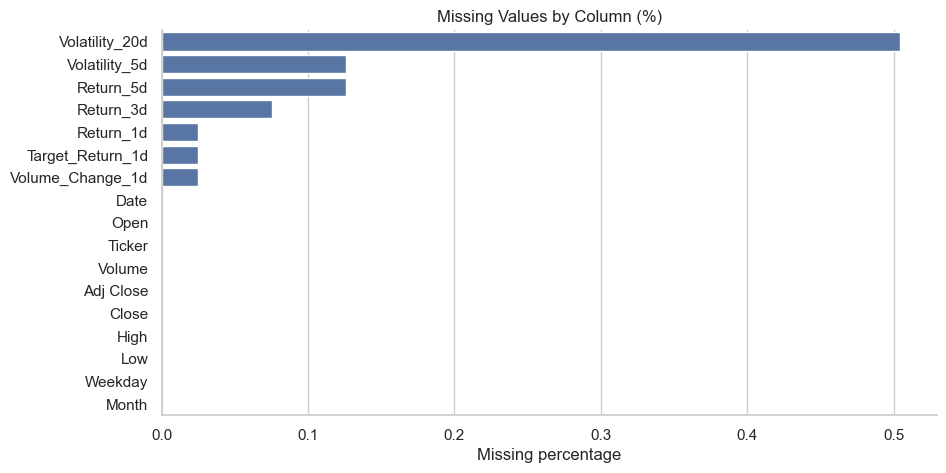

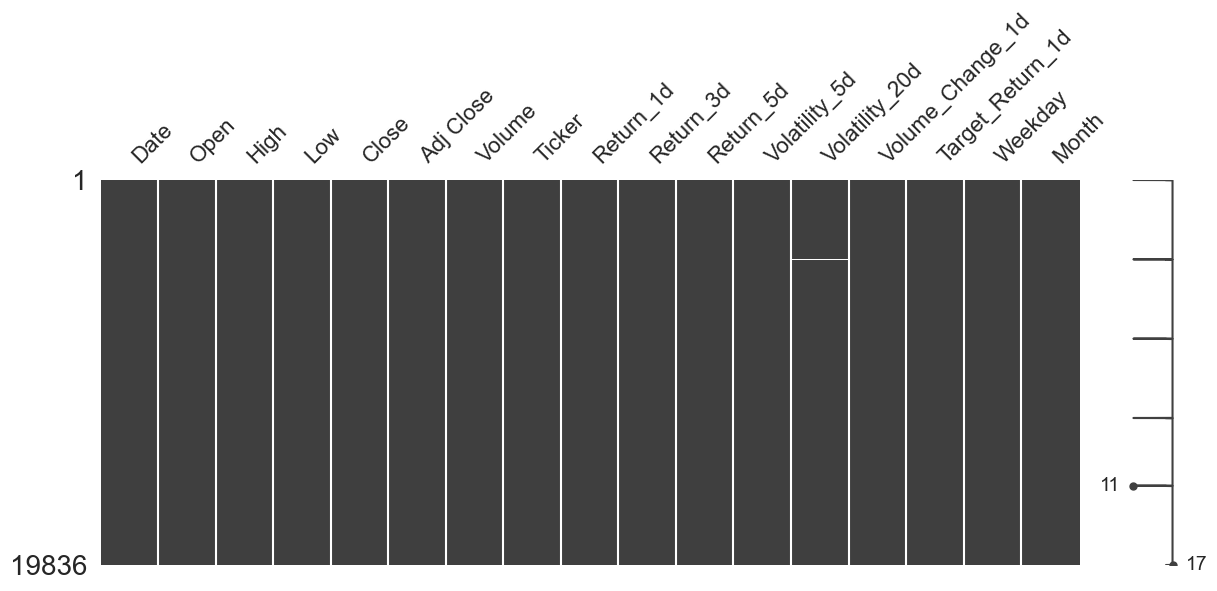

In [10]:
missing_summary = (
    df_eda.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing_Count")
)
missing_summary["Missing_Pct"] = 100 * missing_summary["Missing_Count"] / len(df_eda)
display(missing_summary[missing_summary["Missing_Count"] > 0])

plt.figure(figsize=(10, 5))
sns.barplot(
    data=missing_summary.reset_index().rename(columns={"index": "Column"}),
    x="Missing_Pct",
    y="Column"
)
plt.title("Missing Values by Column (%)")
plt.xlabel("Missing percentage")
plt.ylabel("")
plt.show()

msno.matrix(df_eda, figsize=(14, 5))
plt.show()

## 6. Duplicates

We check both exact duplicates and ticker-date duplicates, since each ticker should normally have only one row per trading day.

In [11]:
exact_duplicates = df_eda.duplicated().sum()
ticker_date_duplicates = df_eda.duplicated(subset=["Ticker", "Date"]).sum()

print("Exact duplicate rows:", exact_duplicates)
print("Ticker-Date duplicate rows:", ticker_date_duplicates)

if ticker_date_duplicates > 0:
    display(
        df_eda[df_eda.duplicated(subset=["Ticker", "Date"], keep=False)]
        .sort_values(["Ticker", "Date"])
        .head(20)
    )

Exact duplicate rows: 0
Ticker-Date duplicate rows: 0


## 7. Adjusted close over time by ticker

This chart helps us compare long-run price trends and major market drawdowns across stocks.

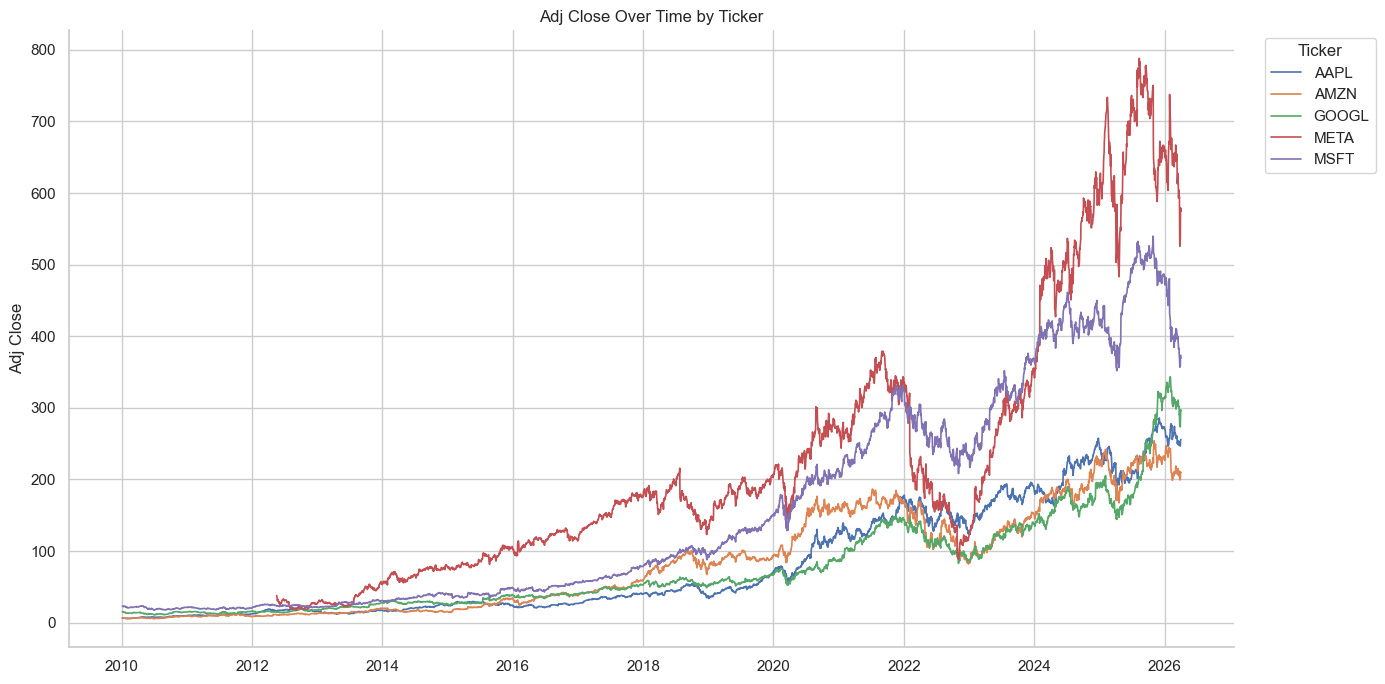

In [12]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_eda, x="Date", y=price_col, hue="Ticker", linewidth=1.2)
plt.title(f"{price_col} Over Time by Ticker")
plt.xlabel("")
plt.ylabel(price_col)
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Price and return distributions

Price levels are usually right-skewed, while daily returns are centered near zero but often have fat tails and outliers.

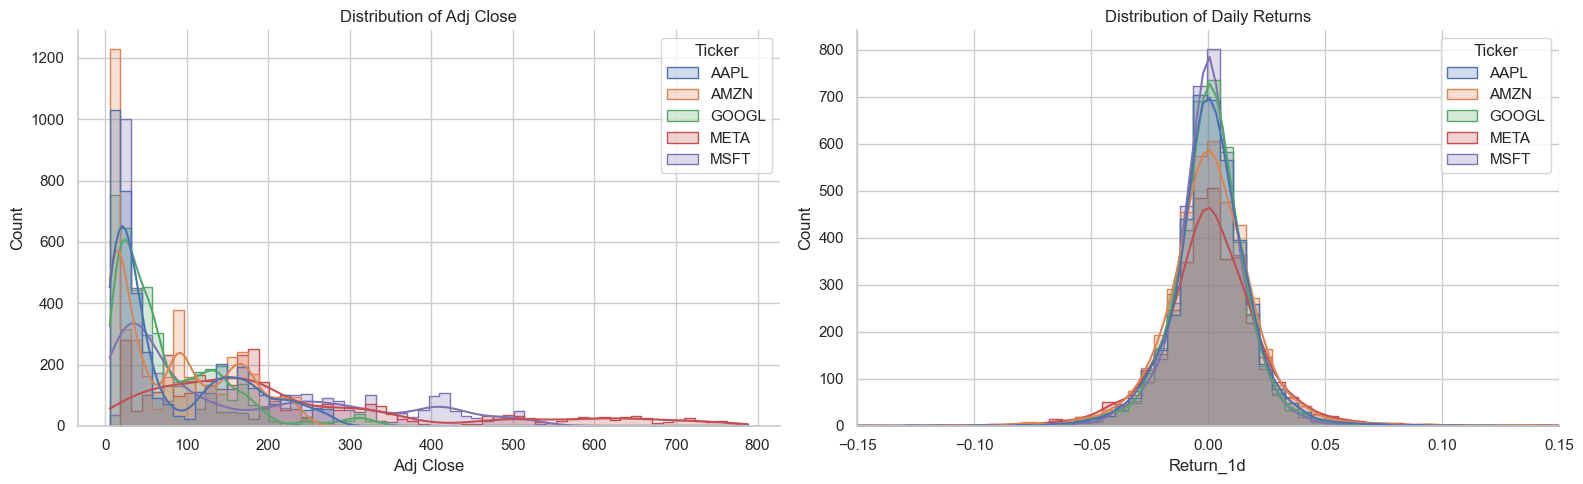

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=df_eda, x=price_col, hue="Ticker", bins=60, kde=True, ax=axes[0], element="step")
axes[0].set_title(f"Distribution of {price_col}")

sns.histplot(
    data=df_eda.dropna(subset=["Return_1d"]),
    x="Return_1d",
    hue="Ticker",
    bins=100,
    kde=True,
    ax=axes[1],
    element="step"
)
axes[1].set_title("Distribution of Daily Returns")
axes[1].set_xlim(-0.15, 0.15)

plt.tight_layout()
plt.show()

## 9. Boxplots of returns by ticker

This makes cross-sectional differences easier to see and highlights which stocks have wider return dispersion.

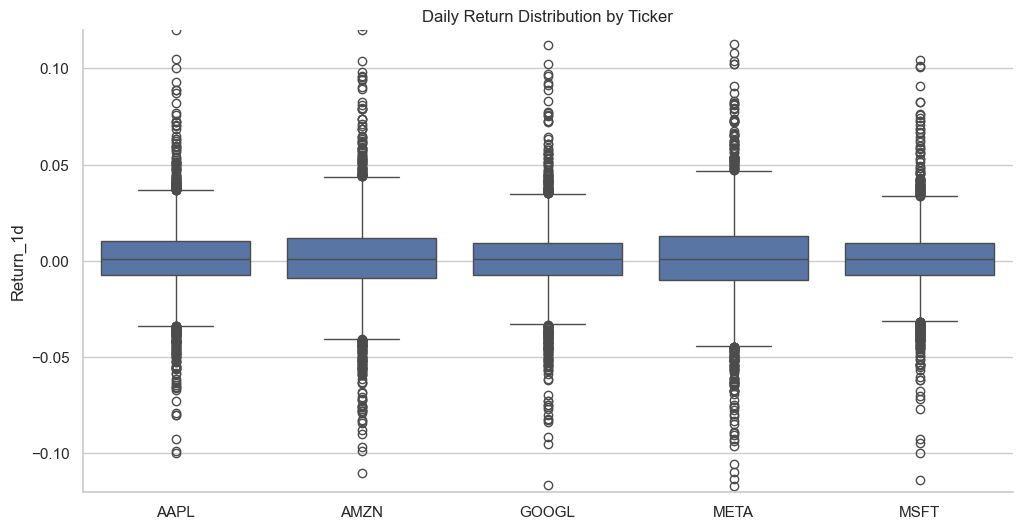

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eda.dropna(subset=["Return_1d"]), x="Ticker", y="Return_1d")
plt.title("Daily Return Distribution by Ticker")
plt.xlabel("")
plt.ylabel("Return_1d")
plt.ylim(-0.12, 0.12)
plt.show()

## 10. Rolling 20-day volatility

Rolling volatility is useful for identifying calm and turbulent periods in the market.

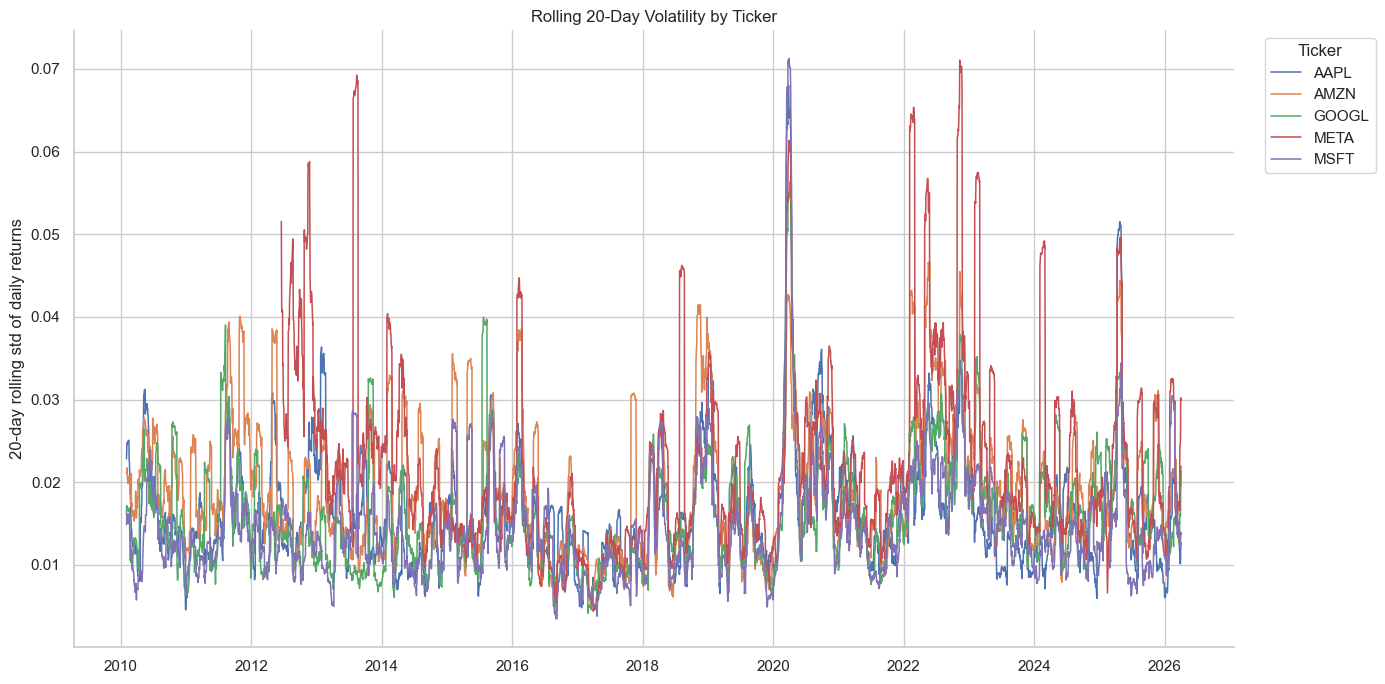

In [15]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_eda, x="Date", y="Volatility_20d", hue="Ticker", linewidth=1.1)
plt.title("Rolling 20-Day Volatility by Ticker")
plt.xlabel("")
plt.ylabel("20-day rolling std of daily returns")
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Volatility clustering

Financial returns often show volatility clustering, meaning large moves tend to be followed by large moves, even if the direction changes.

,,"Corr(abs_return_t, abs_return_t-1)"
Ticker,,
AAPL,Abs_Return_1d,0.192933
AMZN,Abs_Return_1d,0.150455
GOOGL,Abs_Return_1d,0.127628
META,Abs_Return_1d,0.110892
MSFT,Abs_Return_1d,0.214751


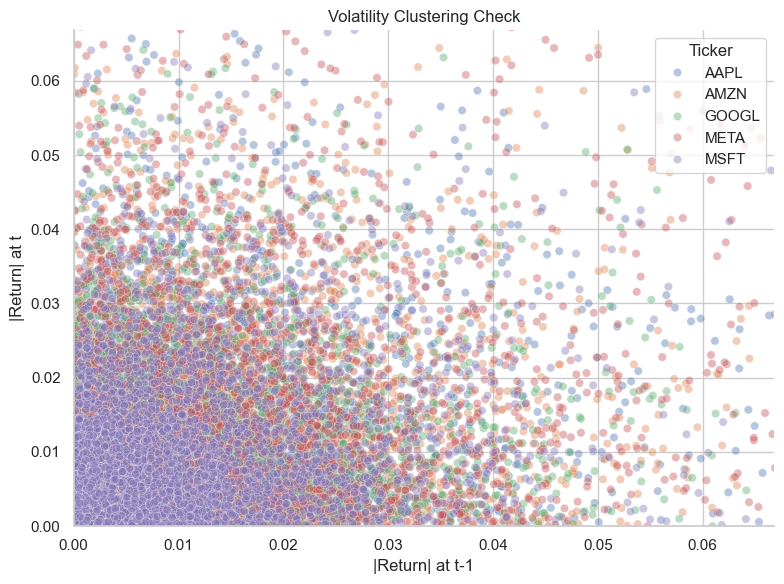

In [16]:
vol_cluster_df = df_eda[["Ticker", "Date", "Return_1d"]].copy()
vol_cluster_df["Abs_Return_1d"] = vol_cluster_df["Return_1d"].abs()
vol_cluster_df["Lag_Abs_Return_1d"] = vol_cluster_df.groupby("Ticker")["Abs_Return_1d"].shift(1)

display(
    vol_cluster_df.groupby("Ticker")[["Abs_Return_1d", "Lag_Abs_Return_1d"]]
    .corr()
    .iloc[0::2, -1]
    .to_frame("Corr(abs_return_t, abs_return_t-1)")
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=vol_cluster_df.dropna(),
    x="Lag_Abs_Return_1d",
    y="Abs_Return_1d",
    hue="Ticker",
    alpha=0.4
)
plt.title("Volatility Clustering Check")
plt.xlabel("|Return| at t-1")
plt.ylabel("|Return| at t")
plt.xlim(0, vol_cluster_df["Lag_Abs_Return_1d"].quantile(0.99))
plt.ylim(0, vol_cluster_df["Abs_Return_1d"].quantile(0.99))
plt.tight_layout()
plt.show()

## 12. Outliers and anomalies

We flag unusually large daily moves using ticker-level z-scores and also inspect the largest absolute returns directly.

In [17]:
anomaly_df = df_eda.dropna(subset=["Return_1d"]).copy()

anomaly_df["Return_Zscore"] = (
    anomaly_df.groupby("Ticker")["Return_1d"]
    .transform(lambda s: zscore(s, nan_policy="omit"))
)

anomaly_df["Anomaly_Flag"] = anomaly_df["Return_Zscore"].abs() > 3

anomaly_summary = (
    anomaly_df.groupby("Ticker")["Anomaly_Flag"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "Anomaly_Count", "mean": "Anomaly_Rate"})
)

display(anomaly_summary)

largest_moves = (
    anomaly_df.assign(Abs_Return=anomaly_df["Return_1d"].abs())
    .sort_values("Abs_Return", ascending=False)
    [["Date", "Ticker", "Return_1d", "Return_Zscore", "Volume"]]
    .head(20)
)

display(largest_moves)

,Anomaly_Count,Anomaly_Rate
Ticker,,
AAPL,57,0.013950
AMZN,62,0.015174
GOOGL,63,0.015419
META,47,0.013479
MSFT,54,0.013216


,Date,Ticker,Return_1d,Return_Zscore,Volume
12557,2013-07-25,META,0.296115,11.784703,365457900
14705,2022-02-03,META,-0.263901,-10.585217,188119900
14889,2022-10-27,META,-0.245571,-9.853016,232316600
14955,2023-02-02,META,0.232824,9.256549,150475700
15206,2024-02-02,META,0.203176,8.072274,84707600
12371,2012-10-24,META,0.191282,7.597149,228949900
13817,2018-07-26,META,-0.189609,-7.617620,169803700
14763,2022-04-28,META,0.175936,6.984151,100890600
9567,2015-07-17,GOOGL,0.162584,9.284992,257162000
4671,2012-04-27,AMZN,0.157457,7.568802,442338000


## 13. Stock-by-stock behavior

Here we compare average return, median return, volatility, and average trading volume across stocks.

,Avg_Return_1d,Median_Return_1d,Std_Return_1d,Avg_Volatility_20d,Avg_Volume,Obs
Ticker,,,,,,
META,0.001093,0.000953,0.025038,0.022055,"28,109,121.158257",3487
AMZN,0.001056,0.000919,0.020666,0.019168,"80,342,434.426230",4086
AAPL,0.001059,0.000979,0.017713,0.016229,"216,358,925.030585",4086
GOOGL,0.000872,0.000878,0.017419,0.016058,"54,617,214.924394",4086
MSFT,0.000812,0.000683,0.016143,0.014754,"35,310,104.746758",4086


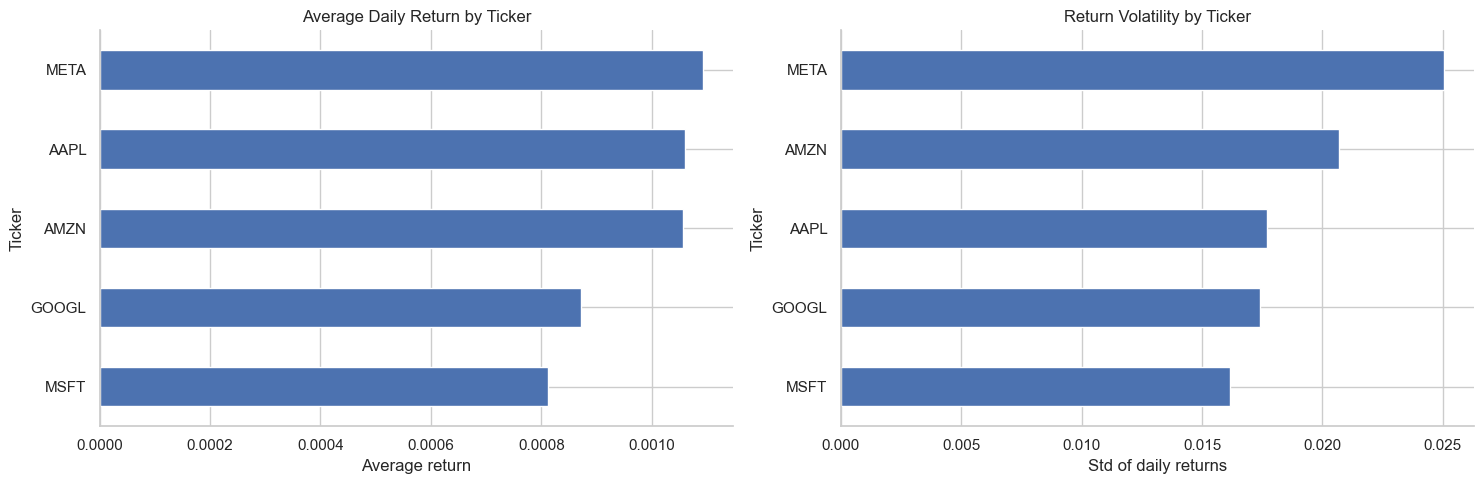

In [18]:
stock_summary = (
    df_eda.groupby("Ticker")
    .agg(
        Avg_Return_1d=("Return_1d", "mean"),
        Median_Return_1d=("Return_1d", "median"),
        Std_Return_1d=("Return_1d", "std"),
        Avg_Volatility_20d=("Volatility_20d", "mean"),
        Avg_Volume=("Volume", "mean"),
        Obs=("Return_1d", "count")
    )
    .sort_values("Std_Return_1d", ascending=False)
)

display(stock_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stock_summary["Avg_Return_1d"].sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Average Daily Return by Ticker")
axes[0].set_xlabel("Average return")

stock_summary["Std_Return_1d"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Return Volatility by Ticker")
axes[1].set_xlabel("Std of daily returns")

plt.tight_layout()
plt.show()

## 14. Calendar effects: weekday and month

These charts check whether average returns differ across weekdays or months.

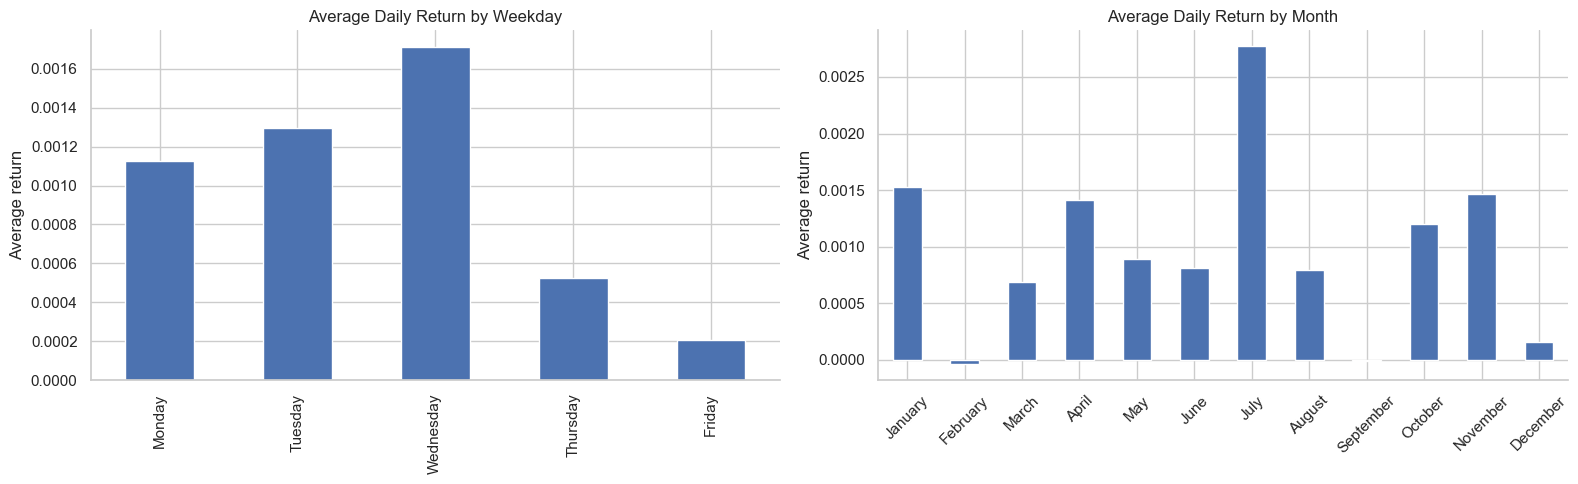

In [19]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

weekday_returns = (
    df_eda.groupby("Weekday")["Return_1d"]
    .mean()
    .reindex(weekday_order)
)

month_returns = (
    df_eda.groupby("Month")["Return_1d"]
    .mean()
    .reindex(month_order)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

weekday_returns.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Daily Return by Weekday")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average return")

month_returns.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Daily Return by Month")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average return")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 15. Correlations between engineered features and target

This is especially useful for the forecasting task, since it shows which features appear most linearly associated with next-day returns.

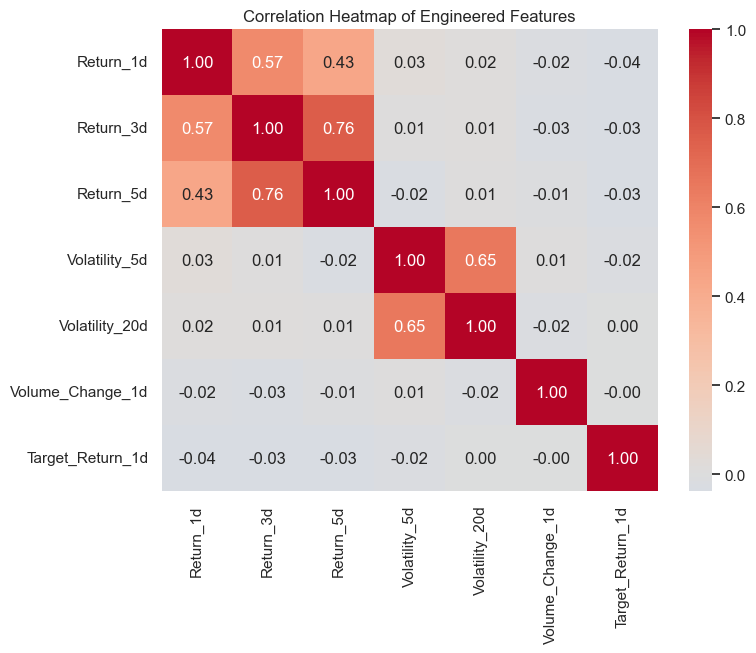

,Correlation_with_Target
Return_1d,-0.038149
Return_5d,-0.032120
Return_3d,-0.031227
Volatility_5d,-0.020695
Volume_Change_1d,-0.002969
Volatility_20d,0.000686


In [20]:
feature_cols = [
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volatility_20d",
    "Volume_Change_1d",
    "Target_Return_1d"
]

available_feature_cols = [col for col in feature_cols if col in df_eda.columns]

corr_df = df_eda[available_feature_cols].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap of Engineered Features")
plt.show()

target_corr = (
    corr_matrix["Target_Return_1d"]
    .drop("Target_Return_1d")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("Correlation_with_Target")
)

display(target_corr)

## 16. Regime differences

We compare selected stress periods with the rest of the sample:
- 2020 crash
- 2022 drawdown
- other periods

,Avg_Return_1d,Median_Return_1d,Std_Return_1d,Avg_Volatility_20d,Obs
Regime,,,,,
2020 Crash,0.000218,-0.003370,0.044651,0.040640,250
2022 Drawdown,-0.001833,-0.001947,0.029041,0.027201,1255
Other,0.001178,0.000976,0.018021,0.016536,18326


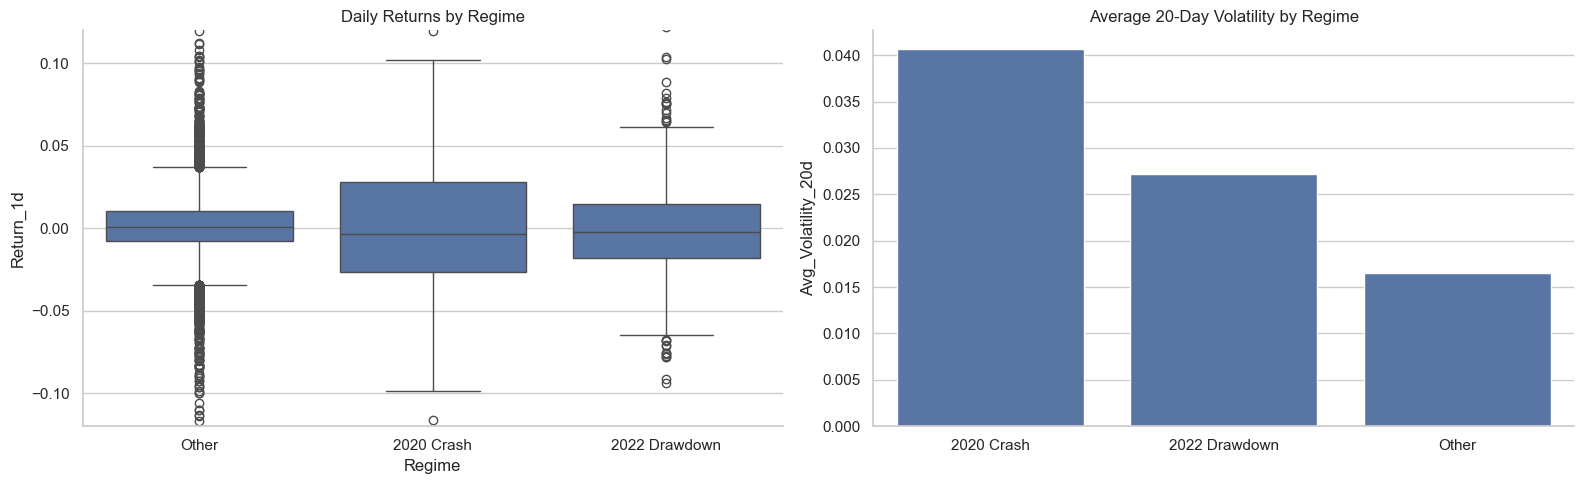

In [21]:
df_regime = df_eda.copy()

conditions = [
    (df_regime["Date"] >= "2020-02-20") & (df_regime["Date"] <= "2020-04-30"),
    (df_regime["Date"] >= "2022-01-01") & (df_regime["Date"] <= "2022-12-31"),
]

choices = ["2020 Crash", "2022 Drawdown"]
df_regime["Regime"] = np.select(conditions, choices, default="Other")

regime_summary = (
    df_regime.groupby("Regime")
    .agg(
        Avg_Return_1d=("Return_1d", "mean"),
        Median_Return_1d=("Return_1d", "median"),
        Std_Return_1d=("Return_1d", "std"),
        Avg_Volatility_20d=("Volatility_20d", "mean"),
        Obs=("Return_1d", "count")
    )
)

display(regime_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_regime.dropna(subset=["Return_1d"]), x="Regime", y="Return_1d", ax=axes[0])
axes[0].set_title("Daily Returns by Regime")
axes[0].set_ylim(-0.12, 0.12)

sns.barplot(
    data=regime_summary.reset_index(),
    x="Regime",
    y="Avg_Volatility_20d",
    ax=axes[1]
)
axes[1].set_title("Average 20-Day Volatility by Regime")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

## 17. Optional: normalized price paths during selected regimes

This gives a cleaner visual comparison of how each stock behaved during stress periods.

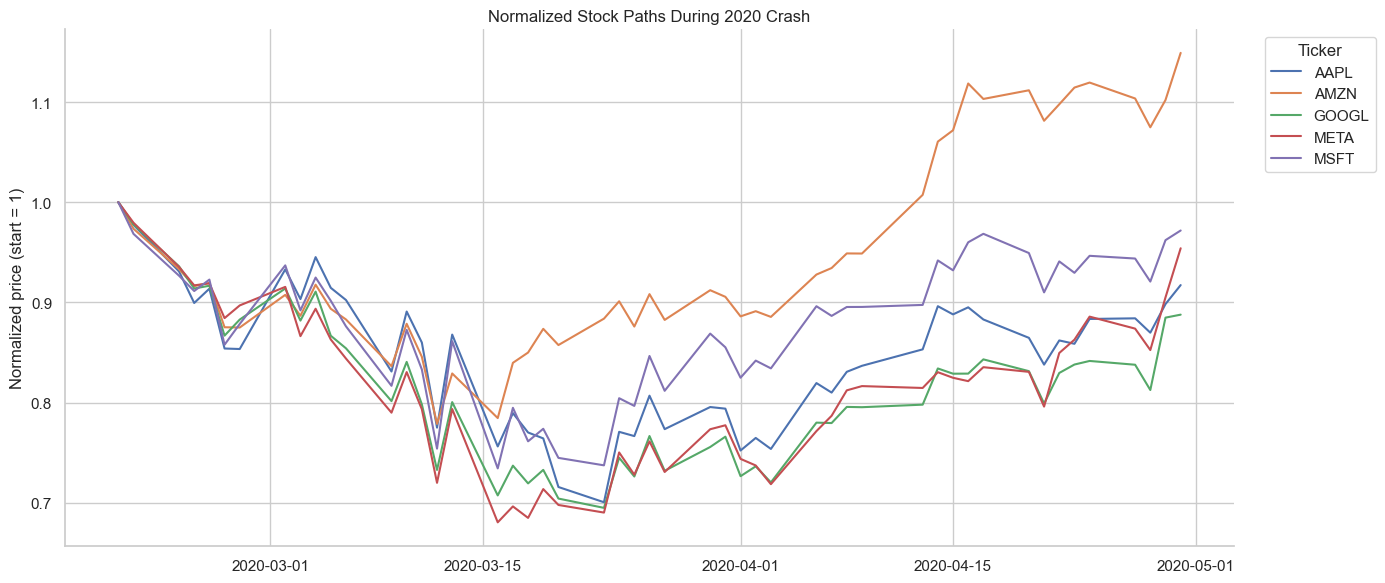

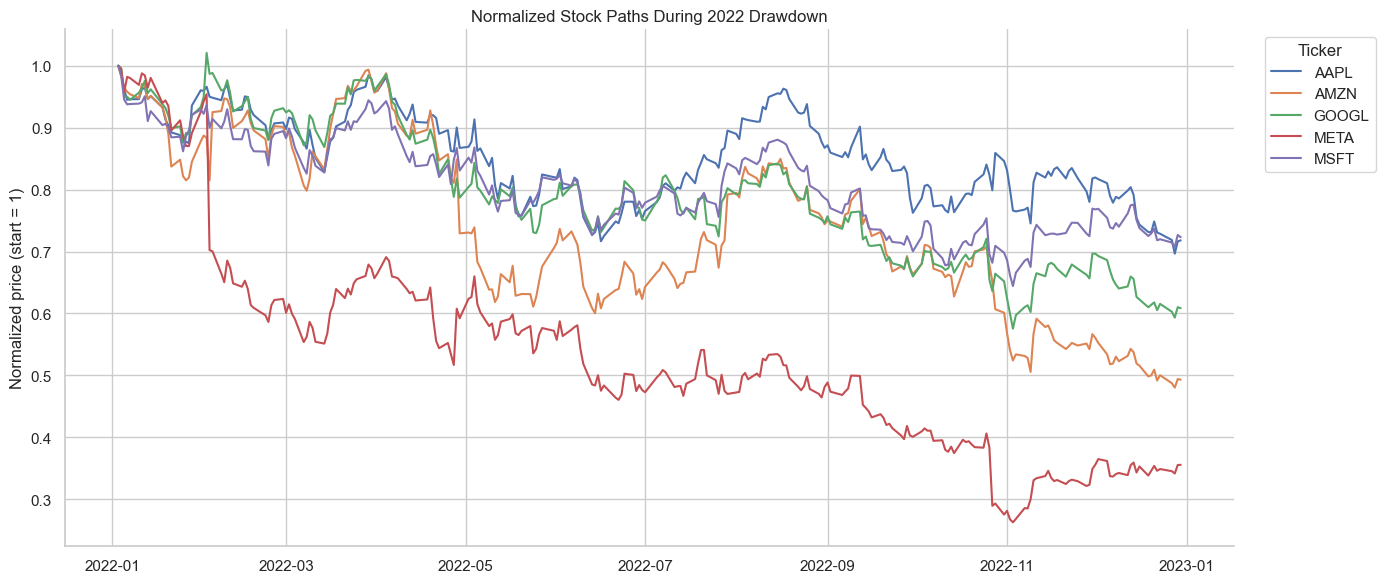

In [22]:
def plot_normalized_period(data, start_date, end_date, title):
    temp = data[(data["Date"] >= start_date) & (data["Date"] <= end_date)].copy()
    temp["Normalized_Price"] = temp.groupby("Ticker")[price_col].transform(lambda s: s / s.iloc[0])

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=temp, x="Date", y="Normalized_Price", hue="Ticker")
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Normalized price (start = 1)")
    plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_normalized_period(df_eda, "2020-02-20", "2020-04-30", "Normalized Stock Paths During 2020 Crash")
plot_normalized_period(df_eda, "2022-01-01", "2022-12-31", "Normalized Stock Paths During 2022 Drawdown")

## 18. EDA takeaways

Write 5–7 concise findings here after reviewing the charts and tables.

Examples of what to comment on:
- whether missing values are mostly caused by lag and rolling-window features
- which stocks are more volatile than others
- whether return distributions show heavy tails or extreme events
- whether volatility clustering is visible
- which engineered features appear most related to next-day returns
- how 2020 and 2022 differ from normal periods
- which findings may affect feature engineering or model design